# Notebook 18 (V4_3) — AHP calibration with $\vartheta_{US}=0.50$

This notebook performs a controlled, one-coordinate counterfactual to Notebook 15's selected `pathwise_hi_exp_pi075` calibration. The baseline uses $\vartheta_{US}=0.85$; the counterfactual restores the obsolete-calibration value $\vartheta_{US}=0.50$. Every other configured structural primitive, numerical seed, evidence window, accounting definition, and hard-validity gate is held fixed.

The official replication comparison uses Notebook 15's $T=30$ path with a 10-period scratch buffer and scores only periods $1{:}15$. Both cases are also warm-extended to $T=60$ without a buffer to diagnose the decay of $\varphi_{US}$, U.S. scale growth, the funding ratio, and U.S. dominance. The $T=60$ extension is reported separately and does not enter the AHP score.

## Identification and verification

The executable analysis asserts that the two configured `ProductionParams` objects differ only in `ϑ_US`. The baseline first-window NFA, valuation, and current-account paths must reproduce Notebook 15's tracked outputs within $10^{-5}$. Both cases are evaluated using Notebook 15's complete model, interiority, accounting, return, foreign-claim, common-growth, and exponent-ordering gates.

The AHP mechanism is considered retained under Notebook 15's original qualitative criterion: negative rebased NFA, negative net and liability valuation effects, valuation larger than current-account flows in absolute value, and average foreign U.S.-equity exposure of at least 0.15. Faster $\varphi_{US}$ decay is reported as a comparative result, not imposed during solution.

  Activating 

Notebook 18: one-coordinate AHP counterfactual


project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Project directory:          /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes
Output directory:           /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_vartheta05_counterfactual
Replication horizon/buffer: 30 / 10
Tail horizon/buffer:        60 / 0
Solving baseline_vartheta085     T=30 buffer=10 branch_iters=60
  max residuals u/bgp = 1.147e-09 / 9.757e-10; hard-valid=true
Solving counterfactual_vartheta050 T=30 buffer=10 branch_iters=60
  max residuals u/bgp = 1.318e-09 / 9.746e-10; hard-valid=true
Solving baseline_vartheta085_tail T=60 buffer=0 branch_iters=60
  max residuals u/bgp = 1.399e-07 / 9.971e-10; hard-valid=true
Solving counterfactual_vartheta050_tail T=60 buffer=0 branch_iters=60
  max residuals u/bgp = 4.707e-07 / 9.746e-10; hard-valid=true


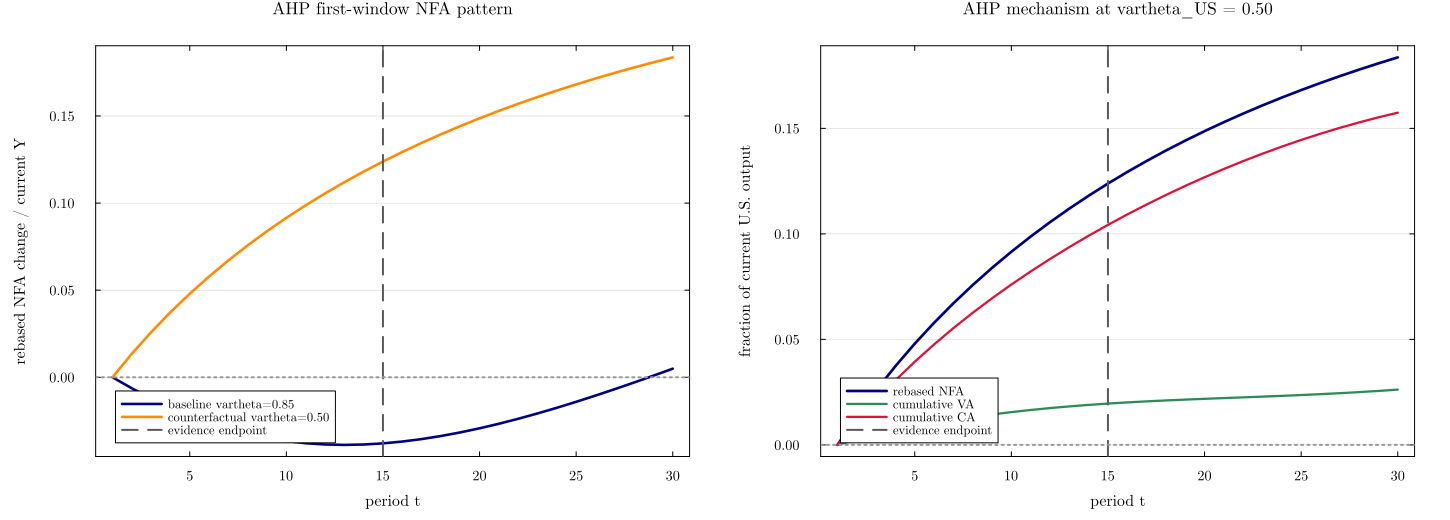

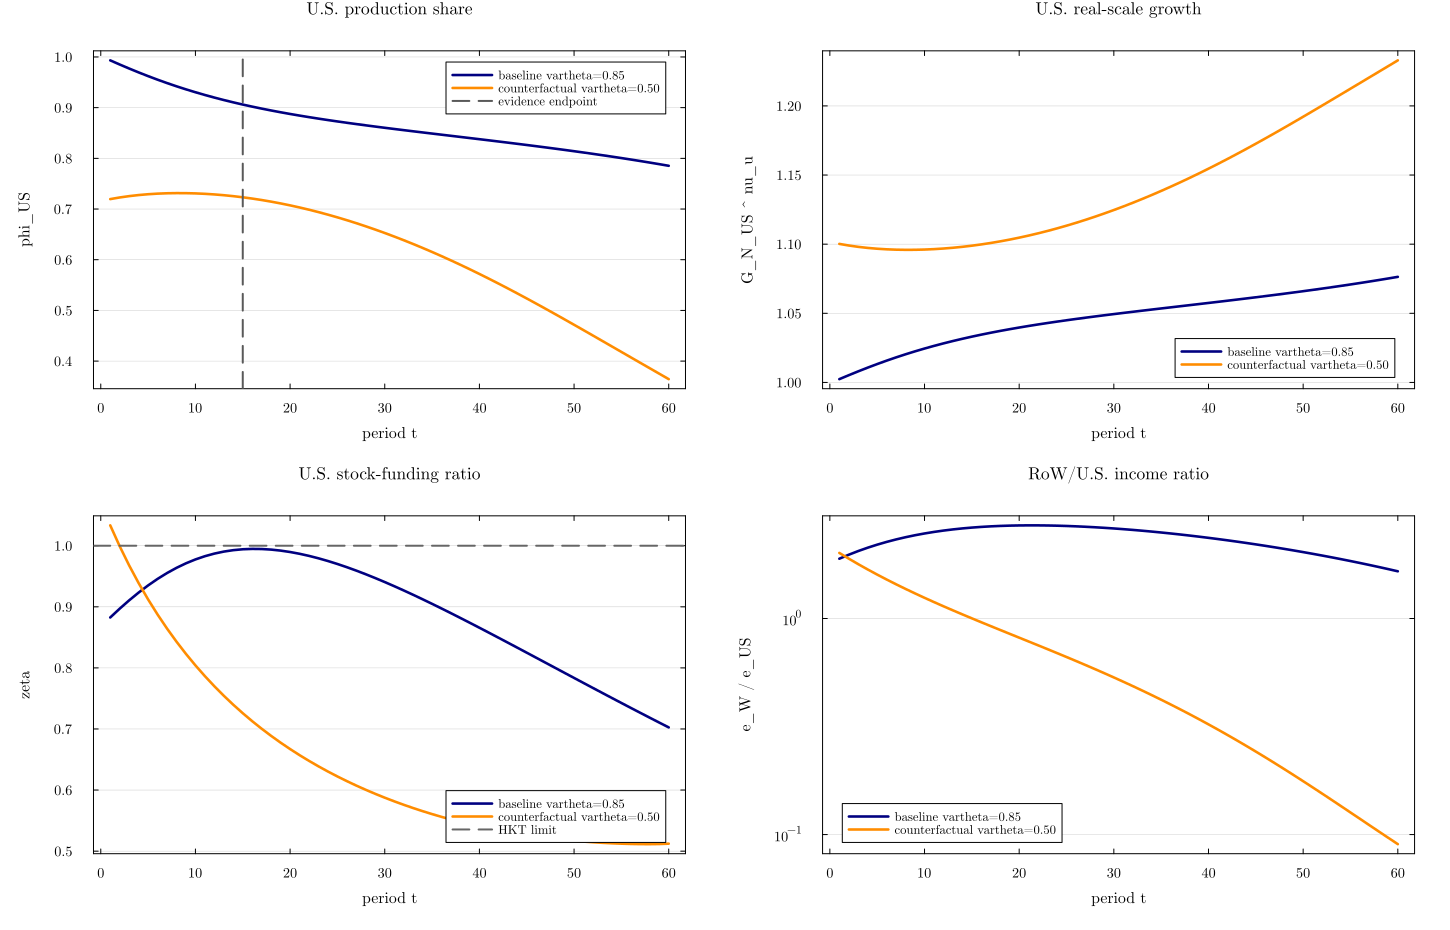


NOTEBOOK 18 — VARTTHETA_US = 0.50 ONE-COORDINATE COUNTERFACTUAL
Configured primitive differences: [:ϑ_US]
Baseline replication max error:    0.000e+00
Counterfactual hard-valid at T30:  true
Counterfactual hard-valid at tail: true
AHP mechanism retained:            false
Faster phi decay than baseline:    true
Joint objective retained:          false
Artifacts written to:              /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_vartheta05_counterfactual


|                       case | vartheta_US | replication*hard*valid | tail*hard*valid | AHP*pattern*pass | target*rebased*NFA | target*net*VA | target_CA | phi*US*t15 | phi*US*t30 | phi*US*tail_end | US*growth*tail_end |
| --------------------------:| -----------:| ----------------------:| ---------------:| ----------------:| ------------------:| -------------:| ---------:| ----------:| ----------:| ---------------:| ------------------:|
|       baseline_vartheta085 |    0.850000 |                   true |            true |             true |          -0.037937 |     -0.048656 |  0.010719 |   0.906101 |   0.860267 |        0.785292 |           1.076354 |
| counterfactual_vartheta050 |    0.500000 |                   true |            true |            false |           0.123858 |      0.019580 |  0.104277 |   0.723166 |   0.652711 |        0.364387 |           1.232961 |


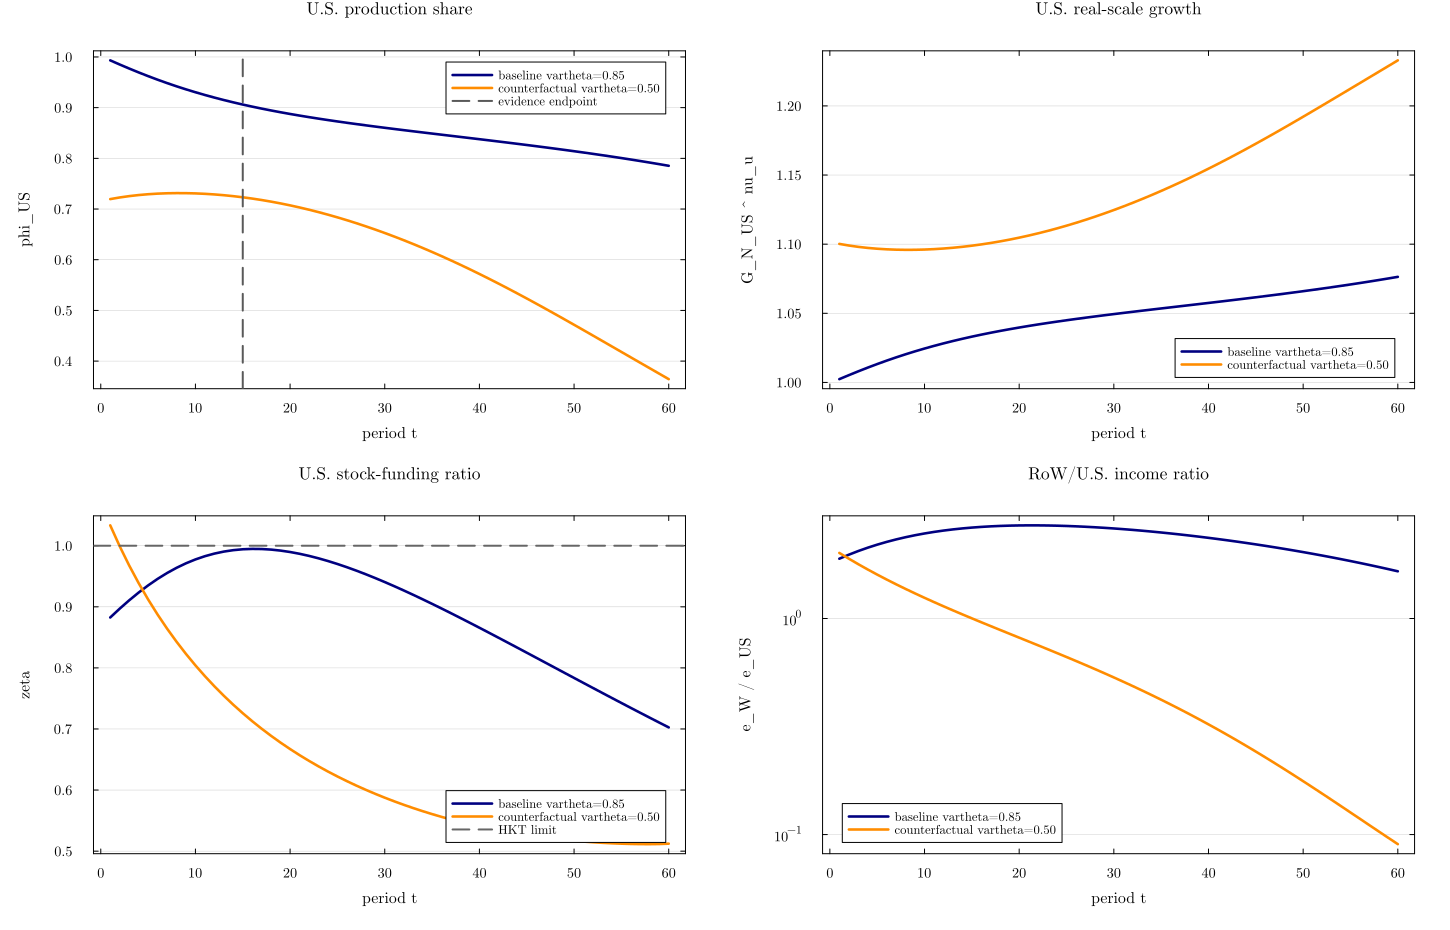

In [1]:
function nb18_find_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not locate Project.toml from $(start_dir)")
        dir = parent
    end
end

nb18_project_dir = nb18_find_project_dir()
include(joinpath(nb18_project_dir, "Two_country_production",
                 "18_v9_ahp_vartheta05_counterfactual.jl"))

## Decision table

The table below separates three questions: numerical admissibility, retention of the first-window AHP mechanism, and the speed of the innovation-share transition. A failure in any one column should not be silently relabeled as a successful joint calibration.

In [2]:
display(markdown_table_18(summary_rows_18, [
    "case", "vartheta_US", "replication_hard_valid", "tail_hard_valid",
    "AHP_pattern_pass", "classification", "target_rebased_NFA",
    "target_net_VA", "target_liability_VA", "target_CA",
    "phi_US_t15", "phi_US_t30", "phi_US_tail_end",
    "first_t_phi_below_050", "first_t_phi_below_020",
]))

println("Joint objective retained: ", joint_objective_retained_18)

|                       case | vartheta_US | replication*hard*valid | tail*hard*valid | AHP*pattern*pass |                                  classification | target*rebased*NFA | target*net*VA | target*liability*VA | target_CA | phi*US*t15 | phi*US*t30 | phi*US*tail_end | first*t*phi*below*050 | first*t*phi*below*020 |
| --------------------------:| -----------:| ----------------------:| ---------------:| ----------------:| -----------------------------------------------:| ------------------:| -------------:| -------------------:| ---------:| ----------:| ----------:| ---------------:| ---------------------:| ---------------------:|
|       baseline_vartheta085 |    0.850000 |                   true |            true |             true | first*window*common*growth*strong*partial*match |          -0.037937 |     -0.048656 |           -0.037059 |  0.010719 |   0.906101 |   0.860267 |        0.785292 |                       |                       |
| counterfactual_vartheta050 |    0.500000 |                   true |            true |            false |            first*window*common*growth*near_miss |           0.123858 |      0.019580 |           -0.015830 |  0.104277 |   0.723166 |   0.652711 |        0.364387 |                    48 |                       |


Joint objective retained: false


## Interpretation discipline

This experiment identifies the effect of changing $\vartheta_{US}$ while holding configured primitives fixed. The common-growth procedure can recalibrate the resolved reference $\nu_b$ differently across the two equilibria; that is an endogenous equilibrium response, not a second configured intervention. `parameter_comparison.csv` records both configured and resolved values so this distinction remains auditable.